## **Green Spaces & Your Well-being: An Urban Exploration**

### Project Overview: What's the Big Idea?

Have you ever wondered how having parks and green areas nearby actually affects how healthy and happy we are? This project is all about diving deep into that question! We'll use some cool mapping and data tricks to see how green spaces are spread out in cities. Then, we'll investigate if neighborhoods with more (or less) access to these green spots tend to have different health outcomes, like how many "bad mental health days" people experience or how common obesity is.

We're basically following a super smart research paper called “Quantifying the Impact of Urban Green Space Access on Physical and Emotional Well‑being: An Integrated Analytics Approach.” Our mission? To re-create their awesome work right here, step-by-step, making it super clear and easy to follow using Python!

### What You'll Learn & Do in This Notebook:

This notebook is your guide through the entire process, from getting our data ready to making beautiful maps and crunching numbers for our final results. Here's what we'll be tackling:

*   **Bringing Data Together:** We'll combine different datasets into one big file, where each row represents a neighborhood (or 'census tract').
*   **Measuring Green Space Access:** We'll create a special score, our very own "Green Space Accessibility Index," to see how easy it is for people to get to green areas.
*   **Spotting Patterns:** We'll use some cool statistical tools (like Moran's I and LISA) to find out if high-access areas tend to clump together, or if low-access areas do.
*   **Understanding Relationships:** We'll dig deeper to see how the connection between green space access and health changes from one neighborhood to another.
*   **Seeing the Story:** We'll visualize everything with maps, charts, and tables to make our findings crystal clear!

Each section below is like a chapter in our adventure, focusing on one main step of the analysis.

### Your Journey Through the Analysis: Key Steps

#### 1. Getting Our Data Ready (Data Preparation)

Think of this as organizing your backpack before a big trip! We'll clean up and merge information from several different sources into one organized dataset. Each row in this dataset will be about a specific neighborhood and will tell us things like:

*   **Who lives there:** Demographic details.
*   **How healthy they are:** Health indicators.
*   **What their environment is like:** Air quality, etc.
*   **Where they are:** Their geographic boundaries.

Our final, super-organized dataset will be saved as a special map file called `tracts_analysis.gpkg`. This will be our main starting point for *all* the exciting analysis to come!

In [ ]:
# Install dependencies
%pip install pandas numpy geopandas shapely pyproj rtree osmnx networkx scikit-learn scipy statsmodels matplotlib seaborn contextily folium esda libpysal mgwr wordcloud openpyxl pyarrow


In [ ]:
!pip install matplotlib-venn

In [ ]:
# https://pypi.python.org/pypi/pydot
!apt-get -qq install -y graphviz && pip install pydot
import pydot

### Getting Our Workspace Ready (Folders & Settings)

Next, we'll set up some important folders for our project. Think of these like creating neatly labeled compartments in your digital workspace! We'll also create a super handy file called `config.py`. Imagine `config.py` as the "control panel" or "brain" of our project – it stores all the important file locations, data paths, and column names. If your data uses different names for things, you might need to pop open `config.py` later and make a few adjustments to match your specific dataset!

In [ ]:
import os

os.makedirs('code', exist_ok=True)
os.makedirs('code/_shared', exist_ok=True)

# Create empty __init__.py files to make them Python packages
open('code/__init__.py', 'w').close() # Use 'w' mode to ensure empty file
open('code/_shared/__init__.py', 'w').close() # Use 'w' mode to ensure empty file

# Define the content of config.py
config_py_content = """from pathlib import Path

# Project root is two levels up from this file: /code/_shared/config.py
ROOT = Path(__file__).resolve().parents[2]

DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
OUTPUT = ROOT / "output"
FIGURES = OUTPUT / "figures"
TABLES = OUTPUT / "tables"
MODELS = OUTPUT / "models"

# Core analysis dataset (one row per census tract)
TRACTS_GPKG = DATA_PROCESSED / "tracts_analysis.gpkg"
TRACTS_LAYER = "tracts"

# Green space polygons (parks/gardens/etc.)
GREENS_GPKG = DATA_PROCESSED / "greenspaces.gpkg"
GREENS_LAYER = "greenspaces"

# Column names in tracts layer
COL_GEOID = "GEOID"
COL_POP = "Population"
COL_MH_DAYS = "Poor_Mental_Health_Days"
COL_PH_DAYS = "Poor_Physical_Health_Days"
COL_OBESITY = "Obesity_Prevalence_Pct"
COL_INCOME = "Median_Household_Income"
COL_EDU = "Bachelors_Degree_Pct"
COL_AQI = "AQI"
COL_POPDENS = "Pop_Density_SqKm"

# If you already computed these in data prep, point to them; otherwise the GSAI script will create them
COL_DIST_NEAREST_KM = "Distance_to_Park_km"
COL_GREEN_M2_800M = "Green_Space_800m_m2"
COL_CONNECTIVITY_RATIO = "Connectivity_Ratio"

# GSAI output columns
COL_GSAI = "GSAI_Score"

# CRS used for distance/area (must be projected, meters)
# Example: EPSG:26918 (NAD83 / UTM zone 18N) – set to your study area
PROJECTED_EPSG = 26918

# Analysis options
BUFFER_M = 800
PROXIMITY_WEIGHT = 0.40
AVAILABILITY_WEIGHT = 0.40
CONNECTIVITY_WEIGHT = 0.20

# Output folders
for p in (FIGURES, TABLES, MODELS):
    p.mkdir(parents=True, exist_ok=True)
"""

with open('code/_shared/config.py', 'w') as f:
    f.write(config_py_content)

print("Created code/_shared/config.py")

Created code/_shared/config.py


### Your Custom Code Assistants (Code Templates!)

Alright, it's time to create the Python code templates for each part of our analysis! Think of these as little assistant scripts that will do the heavy lifting for us. Each script will be saved neatly inside its own file within the `code/` directory. Once your data is all prepped and ready, you can run these scripts one by one to complete the analysis, like following a recipe to bake a delicious cake!

These code templates are built exactly according to **Section 3: Methodology** of the research paper we're following. Each script handles a crucial part of the analysis, making sure our work is clear, repeatable, and easy to share – just like following instructions in a science experiment!

#### 1. Getting Your Data Shipshape: `01_build_analysis_layer.py`

This script is your very first step in getting the data ready for prime time! It takes all our different input data sources and combines them into one clean, super-file for each neighborhood (`tracts_analysis.gpkg`). **Important:** Before you run this, make sure your raw data files (like `tracts_boundary.gpkg`, `acs_tract.csv`, `cdc_places_tract.csv`, and `aqi_tract.csv`) are all neatly placed in the `data/processed` folder. Think of it like gathering all your ingredients before you start cooking!

This script is directly inspired by **Section 3.1: Study Area and Data Sources** from the research paper. It brings together all our different data sources into that single `tracts_analysis.gpkg` file. Just a heads-up: the paper mentions a fancy way to handle missing data called MICE, but this template keeps it simple. If you want to use MICE, you'd need to add that extra code yourself – consider it an advanced optional step for future explorations!

In [ ]:
# Create 01_build_analysis_layer.py
import os
os.makedirs('code/01_data_prep', exist_ok=True)

file_content = """import pandas as pd\nimport geopandas as gpd\nfrom code._shared.config import (\n    DATA_PROCESSED, TRACTS_GPKG, TRACTS_LAYER, PROJECTED_EPSG,\n    COL_GEOID\n)\n\n# NOTE: Replace these with your actual intermediate files if they exist\nTRACTS_SHAPEFILE = DATA_PROCESSED / "tracts_boundary.gpkg"\nTRACTS_BOUNDARY_LAYER = "tracts_boundary"\n\nACS_CSV = DATA_PROCESSED / "acs_tract.csv"\nPLACES_CSV = DATA_PROCESSED / "cdc_places_tract.csv"\nAQI_CSV = DATA_PROCESSED / "aqi_tract.csv"\n\nOUT_GPKG = TRACTS_GPKG\nOUT_LAYER = TRACTS_LAYER\n\ndef main():\n    tracts = gpd.read_file(TRACTS_SHAPEFILE, layer=TRACTS_BOUNDARY_LAYER)\n\n    # Standardize GEOID to string\n    tracts[COL_GEOID] = tracts[COL_GEOID].astype(str)\n\n    acs = pd.read_csv(ACS_CSV, dtype={COL_GEOID: str})\n    places = pd.read_csv(PLACES_CSV, dtype={COL_GEOID: str})\n    aqi = pd.read_csv(AQI_CSV, dtype={COL_GEOID: str})\n\n    df = acs.merge(places, on=COL_GEOID, how="left").merge(aqi, on=COL_GEOID, how="left")\n\n    # Basic missing handling example (adapt to your needs)\n    # df = df.fillna(df.median(numeric_only=True))\n\n    gdf = tracts.merge(df, on=COL_GEOID, how="left")\n\n    # Use projected CRS for distances/areas\n    gdf = gdf.to_crs(epsg=PROJECTED_EPSG)\n\n    # Persist\n    gdf.to_file(OUT_GPKG, layer=OUT_LAYER, driver="GPKG")\n    print(f"Wrote {OUT_GPKG} layer={OUT_LAYER} rows={len(gdf):,}")\n\nif __name__ == "__main__":\n    main()"""

with open('code/01_data_prep/01_build_analysis_layer.py', 'w') as f:
    f.write(file_content)

print("Created code/01_data_prep/01_build_analysis_layer.py")


Created code/01_data_prep/01_build_analysis_layer.py


#### 2. Calculating Your Green Space Score (GSAI): `02_compute_gsai.py`

This script is where the magic happens for our Green Space Accessibility Index (GSAI)! It crunches the numbers to give each neighborhood a score based on how close green spaces are (proximity), how much green space is available (availability), and how well-connected they are. It then adds this new GSAI score right into our `tracts_analysis.gpkg` file. **Don't forget:** Make sure your `greenspaces.gpkg` file is chilling in the `data/processed` folder, ready to be used!

This script is a direct implementation of **Section 3.2: Green Space Accessibility Index (GSAI)** from our research paper. It figures out three key scores: Proximity (how close?), Availability (how much?), and Connectivity (how easy to get to?). These scores are then standardized (put on a 0-100 scale) and combined into the final GSAI using specific weights (Proximity: 40%, Availability: 40%, Connectivity: 20%). You'll also notice `BUFFER_M = 800`, which means we're looking at green spaces within 800 meters – just like the paper! One thing to note: the `compute_connectivity_ratio_placeholder` function is a simplified version. To fully match the paper's advanced network analysis, you'd need to swap that out with a more complex implementation, perhaps using a tool like OSMnx to truly map out the paths people take.

In [ ]:
# Create 02_compute_gsai.py
import os
os.makedirs('code/02_gsai', exist_ok=True)

file_content = """import numpy as np\nimport geopandas as gpd\nfrom shapely.geometry import Point\n\nfrom sklearn.preprocessing import MinMaxScaler\n\nfrom code._shared.config import (\n    TRACTS_GPKG, TRACTS_LAYER, GREENS_GPKG, GREENS_LAYER, PROJECTED_EPSG,\n    BUFFER_M, PROXIMITY_WEIGHT, AVAILABILITY_WEIGHT, CONNECTIVITY_WEIGHT,\n    COL_POP, COL_DIST_NEAREST_KM, COL_GREEN_M2_800M, COL_CONNECTIVITY_RATIO,\n    COL_GSAI\n)\n\n\ndef _ensure_projected(gdf, epsg):\n    if gdf.crs is None or gdf.crs.to_epsg() != epsg:\n        gdf = gdf.to_crs(epsg=epsg)\n    return gdf\n\n\ndef compute_distance_to_nearest_green_km(tracts, greens):\n    # Use centroids for tract location\n    centroids = tracts.geometry.centroid\n    cent_gdf = gpd.GeoDataFrame(tracts.drop(columns="geometry"), geometry=centroids, crs=tracts.crs)\n\n    # Spatial index nearest join to green polygons\n    nearest = gpd.sjoin_nearest(cent_gdf, greens[["geometry"]], how="left", distance_col="dist_m")\n    return nearest["dist_m"].astype(float) / 1000.0\n\n\ndef compute_green_area_within_buffer_m2(tracts, greens, buffer_m=800):\n    centroids = tracts.geometry.centroid\n    buffers = gpd.GeoSeries(centroids.buffer(buffer_m), crs=tracts.crs)\n    buf_gdf = gpd.GeoDataFrame(tracts[[COL_POP]].copy(), geometry=buffers)\n\n    # Intersect greens with buffers and sum intersected area\n    inter = gpd.overlay(greens[["geometry"]].copy(), buf_gdf.reset_index().rename(columns={"index": "tract_idx"}), how="intersection")\n    inter["area_m2"] = inter.geometry.area\n    area_by_tract = inter.groupby("tract_idx")["area_m2"].sum()\n\n    out = np.zeros(len(tracts), dtype=float)\n    out[area_by_tract.index.values] = area_by_tract.values\n    return out\n\n\ndef compute_connectivity_ratio_placeholder(tracts):\n    # Placeholder: if you have an OSMnx-based network analysis already, write it into COL_CONNECTIVITY_RATIO.\n    # For reproducibility, we default to 1.0 (= network distance ~= euclidean distance).\n    return np.ones(len(tracts), dtype=float)\n\n\ndef main():\n    tracts = gpd.read_file(TRACTS_GPKG, layer=TRACTS_LAYER)\n    greens = gpd.read_file(GREENS_GPKG, layer=GREENS_LAYER)\n\n    tracts = _ensure_projected(tracts, PROJECTED_EPSG)\n    greens = _ensure_projected(greens, PROJECTED_EPSG)\n\n    # 1) Proximity score: 1 / (1 + dist_km)\n    if COL_DIST_NEAREST_KM not in tracts.columns:\n        tracts[COL_DIST_NEAREST_KM] = compute_distance_to_nearest_green_km(tracts, greens)\n    tracts["proximity_raw"] = 1.0 / (1.0 + tracts[COL_DIST_NEAREST_KM].astype(float))\n\n    # 2) Availability score: green area within 800m per capita\n    if COL_GREEN_M2_800M not in tracts.columns:\n        tracts[COL_GREEN_M2_800M] = compute_green_area_within_buffer_m2(tracts, greens, BUFFER_M)\n    tracts["availability_raw"] = tracts[COL_GREEN_M2_800M].astype(float) / tracts[COL_POP].replace(0, np.nan).astype(float)\n    tracts["availability_raw"] = tracts["availability_raw"].fillna(0.0)\n\n    # 3) Connectivity score: lower ratio is better → invert\n    if COL_CONNECTIVITY_RATIO not in tracts.columns:\n        tracts[COL_CONNECTIVITY_RATIO] = compute_connectivity_ratio_placeholder(tracts)\n    # Convert ratio to a "higher is better" measure\n    tracts["connectivity_raw"] = 1.0 / tracts[COL_CONNECTIVITY_RATIO].replace(0, np.nan).astype(float)\n    tracts["connectivity_raw"] = tracts["connectivity_raw"].fillna(0.0)\n\n    # Normalize each component to 0–100\n    scaler = MinMaxScaler(feature_range=(0, 100))\n    comps = tracts[["proximity_raw", "availability_raw", "connectivity_raw"]].astype(float).values\n    comps_norm = scaler.fit_transform(comps)\n    tracts["proximity_0_100"] = comps_norm[:, 0]\n    tracts["availability_0_100"] = comps_norm[:, 1]\n    tracts["connectivity_0_100"] = comps_norm[:, 2]\n\n    # Weighted composite\n    tracts[COL_GSAI] = (\n        PROXIMITY_WEIGHT * tracts["proximity_0_100"]\n        + AVAILABILITY_WEIGHT * tracts["availability_0_100"]\n        + CONNECTIVITY_WEIGHT * tracts["connectivity_0_100"]\n    )\n\n    # Save back to same file\n    tracts.to_file(TRACTS_GPKG, layer=TRACTS_LAYER, driver="GPKG")\n    print(f"Updated {TRACTS_GPKG} with {COL_GSAI}")\n\nif __name__ == "__main__":\n    main()"""

with open('code/02_gsai/02_compute_gsai.py', 'w') as f:
    f.write(file_content)

print("Created code/02_gsai/02_compute_gsai.py")


Created code/02_gsai/02_compute_gsai.py


#### 3. Finding Spatial Hotspots & Coldspots (Moran's I & LISA): `03_morans_lisa.py`

This script is all about uncovering hidden spatial patterns! We'll use two powerful tools, Global Moran's I and Local Indicators of Spatial Association (LISA), to see if our GSAI scores (Green Space Accessibility Index) are clustered together. Think of it like finding "hot spots" where many neighborhoods have high green space access, or "cold spots" where many have low access. This script will give us some neat tables and, even cooler, update our `tracts_analysis.gpkg` file with labels showing where these 'hotspots' (High-High clusters) and 'coldspots' (Low-Low clusters) of green space accessibility are!

In [ ]:
# Create 03_morans_lisa.py
import os
os.makedirs('code/03_spatial', exist_ok=True)

file_content = """# Removed: import sys and sys.path.insert(0, '/content/')

import numpy as np
import pandas as pd
import geopandas as gpd

from libpysal.weights import KNN # Changed from Queen to KNN
from esda.moran import Moran
from esda.moran import Moran_Local

from code._shared.config import (
    TRACTS_GPKG, TRACTS_LAYER, TABLES, FIGURES,
    COL_GSAI, COL_GEOID
)


def lisa_cluster_labels(local_moran, p=0.05):
    # Quadrant labels based on Moran scatterplot quadrants
    # 1 HH, 2 LH, 3 LL, 4 HL in esda convention for q
    q = local_moran.q
    sig = local_moran.p_sim <= p

    labels = np.array(["Not significant"] * len(q), dtype=object)
    labels[sig & (q == 1)] = "High-High"
    labels[sig & (q == 2)] = "Low-High"
    labels[sig & (q == 3)] = "Low-Low"
    labels[sig & (q == 4)] = "High-Low"
    return labels


def main():
    gdf = gpd.read_file(TRACTS_GPKG, layer=TRACTS_LAYER)
    y = gdf[COL_GSAI].astype(float).values

    # KNN weights to ensure connectivity, row-standardized
    # k=4 is a common choice for grid-like data
    w = KNN.from_dataframe(gdf, k=4) # Changed from Queen
    w.transform = "R"

    # Global Moran's I
    mi = Moran(y, w, permutations=999)
    global_out = pd.DataFrame([{
        "moran_I": mi.I,
        "expected_I": mi.EI,
        "variance": mi.VI_norm,
        "z_score": mi.z_norm,
        "p_value": mi.p_norm,
        "permutations_p_sim": mi.p_sim
    }])
    global_out.to_csv(TABLES / "global_morans_i_gsai.csv", index=False)

    # Local Moran (LISA)
    lisa = Moran_Local(y, w, permutations=999)
    gdf["lisa_I"] = lisa.Is
    gdf["lisa_p"] = lisa.p_sim
    gdf["lisa_cluster"] = lisa_cluster_labels(lisa, p=0.05)

    # Save tract layer with clusters
    gdf.to_file(TRACTS_GPKG, layer=TRACTS_LAYER, driver="GPKG")

    # Cluster counts table (matches the report-style summary)
    counts = (gdf["lisa_cluster"]
              .value_counts()
              .rename_axis("cluster")
              .reset_index(name="tract_count"))
    counts["percent"] = 100.0 * counts["tract_count"] / len(gdf)
    counts.to_csv(TABLES / "lisa_cluster_counts.csv", index=False)

    print("Saved Moran's I and LISA outputs to output/tables and updated tracts layer.")

if __name__ == "__main__":
    main()"""

with open('code/03_spatial/03_morans_lisa.py', 'w') as f:
    f.write(file_content)

print("Created code/03_spatial/03_morans_lisa.py")


Created code/03_spatial/03_morans_lisa.py


#### 4. Understanding Local Relationships (Geographically Weighted Regression - GWR): `04_run_gwr.py`

This script gets super interesting! It runs a Geographically Weighted Regression (GWR) model, which helps us understand how relationships between different factors *change from one location to another*. Imagine how the impact of green space on health might be different in a bustling city center compared to a quiet suburb – GWR helps us see that! It will give us values like 'local R²' (how well our model explains things in a specific area) and 'coefficient surfaces' (how the impact of one factor changes across space). All these cool, localized results will be added to our `tracts_analysis.gpkg` file!

This script is a direct implementation of **Section 3.4: Geographically Weighted Regression (GWR)** from the research paper. It performs a GWR analysis to investigate how the connection between our Green Space Accessibility Index (GSAI) and health outcomes changes across different places. Just like in the paper, we'll be using `COL_MH_DAYS` (Poor Mental Health Days) as our main outcome we're trying to explain, and GSAI along with other social and economic factors as our predictors. This helps us see that a "one size fits all" solution often isn't the best in urban planning!

In [ ]:
# Create 04_run_gwr.py
import os
os.makedirs('code/04_gwr', exist_ok=True)

file_content = """# Removed: import sys and sys.path.insert(0, '/content/')

import numpy as np
import pandas as pd
import geopandas as gpd

from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW

from code._shared.config import (
    TRACTS_GPKG, TRACTS_LAYER, TABLES,
    COL_GSAI, COL_MH_DAYS, COL_INCOME, COL_EDU, COL_AQI, COL_POPDENS
)


def zscore(a):
    a = a.astype(float)
    return (a - a.mean()) / a.std(ddof=0)


def main():
    gdf = gpd.read_file(TRACTS_GPKG, layer=TRACTS_LAYER)

    # Coordinates for GWR (use projected CRS meters)
    # mgwr expects an (n,2) array: [x, y]
    cent = gdf.geometry.centroid
    coords = np.column_stack([cent.x.values, cent.y.values])

    # Dependent variable (example: poor mental health days)
    y = gdf[COL_MH_DAYS].astype(float).values.reshape((-1, 1))

    # Predictors (include intercept automatically by adding a column of ones)
    X = np.column_stack([
        np.ones(len(gdf)),
        zscore(gdf[COL_GSAI].values),
        zscore(np.log1p(gdf[COL_INCOME].values)),
        zscore(gdf[COL_EDU].values),
        zscore(gdf[COL_AQI].values),
        zscore(gdf[COL_POPDENS].values),
    ])
    x_names = ["Intercept", "GSAI_z", "log_income_z", "edu_z", "aqi_z", "popdens_z"]

    # Bandwidth selection (adaptive by default)
    selector = Sel_BW(coords, y, X, spherical=False)
    bw = selector.search(bw_min=30)

    model = GWR(coords, y, X, bw)
    res = model.fit()

    # Write summary table (global-style)
    summary = pd.DataFrame({
        "term": x_names,
        "coef_mean": res.params.mean(axis=0),
        "coef_min": res.params.min(axis=0),
        "coef_max": res.params.max(axis=0),
    })
    summary.to_csv(TABLES / "gwr_coefficient_summary.csv", index=False)

    # Attach local outputs back to GeoDataFrame
    for j, nm in enumerate(x_names):
        gdf[f"gwr_{nm}"] = res.params[:, j]

    gdf["gwr_local_r2"] = res.localR2

    # Save updated layer
    gdf.to_file(TRACTS_GPKG, layer=TRACTS_LAYER, driver="GPKG")

    # Persist model diagnostics
    diag = pd.DataFrame([{
        "bandwidth": bw,
        "aicc": res.aicc,
        "rss": res.RSS,
        "enp": res.ENP
    }])
    diag.to_csv(TABLES / "gwr_diagnostics.csv", index=False)

    print("GWR complete. Wrote coefficient summary + diagnostics and updated tracts layer with local outputs.")

if __name__ == "__main__":
    main()"""

with open('code/04_gwr/04_run_gwr.py', 'w') as f:
    f.write(file_content)

print("Created code/04_gwr/04_run_gwr.py")

Created code/04_gwr/04_run_gwr.py


#### 5. Bringing It All to Life (Tables & Figures): `06_make_tables_and_figures.py`

This is where all our hard work pays off visually! This script will generate a bunch of awesome tables and figures – like a correlation matrix (how different things relate to each other), a map of GSAI scores, a map showing our LISA clusters (hotspots/coldspots), and maps of our GWR results. All these will be saved neatly into our `output/tables` and `output/figures` folders for you to explore! Get ready to see your data come alive!

This script helps us show off our **Results (Section 4)** and plays a role in explaining our analysis workflow in **Section 3.6 (Stage 1: Descriptive Analytics & Stage 3: Integration & Recommendations)**. It creates those handy correlation matrices and all sorts of colorful maps (like GSAI, LISA clusters, and GWR outputs) that are talked about in the paper's results. Plus, there's even a spot here for a 'word cloud' from any survey responses you might have, connecting back to **Section 3.5: Survey design and mixed methods** and **Section 4.5: Survey results**! It's how we tell the story of our findings visually.

In [ ]:
# Create 06_make_tables_and_figures.py
import os
os.makedirs('code/06_visualization', exist_ok=True)

file_content = """# Removed: import sys and sys.path.insert(0, '/content/')

import re
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from code._shared.config import (
    TRACTS_GPKG, TRACTS_LAYER, FIGURES, TABLES,
    COL_GSAI, COL_MH_DAYS, COL_PH_DAYS, COL_OBESITY, COL_INCOME, COL_EDU, COL_AQI, COL_POPDENS
)


def save_corr_matrix(df, out_csv, out_png):
    corr = df.corr(numeric_only=True)
    corr.to_csv(out_csv)

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close()


def plot_choropleth(gdf, column, title, out_png, cmap="viridis"):
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    gdf.plot(column=column, ax=ax, legend=True, cmap=cmap, linewidth=0.0)
    ax.set_axis_off()
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close()


def make_wordcloud(texts, out_png):
    joined = " ".join([t for t in texts if isinstance(t, str) and t.strip()])
    joined = re.sub(r"\\s+", " ", joined) # Corrected this line with doubly escaped backslash and raw string literal
    wc = WordCloud(width=1200, height=800, background_color="white").generate(joined)
    plt.figure(figsize=(12, 8))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close()


def main():
    gdf = gpd.read_file(TRACTS_GPKG, layer=TRACTS_LAYER)

    # --- Table C1: correlation matrix (example variables)
    df = gdf[[COL_GSAI, COL_MH_DAYS, COL_PH_DAYS, COL_OBESITY, COL_INCOME, COL_EDU, COL_AQI, COL_POPDENS]].copy()
    save_corr_matrix(
        df,
        TABLES / "table_c1_correlation_matrix.csv",
        FIGURES / "table_c1_correlation_heatmap.png"
    )

    # --- Figure C1: GSAI map
    plot_choropleth(gdf, COL_GSAI, "Figure C1: GSAI Distribution", FIGURES / "figure_c1_gsai_map.png")

    # --- Figure C2: LISA cluster map (requires lisa_cluster column from 03_morans_lisa.py)
    if "lisa_cluster" in gdf.columns:
        # Simple categorical coloring using pandas codes
        gdf["lisa_code"] = gdf["lisa_cluster"].astype("category").cat.codes
        plot_choropleth(gdf, "lisa_code", "Figure C2: LISA Clusters (coded)", FIGURES / "figure_c2_lisa_clusters.png", cmap="tab20")
        gdf.drop(columns=["lisa_code"], inplace=True)

    # --- Figure C3: GWR local R2 surface
    if "gwr_local_r2" in gdf.columns:
        plot_choropleth(gdf, "gwr_local_r2", "Figure C3: GWR Local R²", FIGURES / "figure_c3_gwr_local_r2.png", cmap="magma")

    # --- Figure C4: GWR coefficient surface for GSAI term
    # In 04_run_gwr.py, the GSAI coefficient column is gwr_GSAI_z
    if "gwr_GSAI_z" in gdf.columns:
        plot_choropleth(gdf, "gwr_GSAI_z", "Figure C4: GWR GSAI Coefficient (standardized)", FIGURES / "figure_c4_gwr_gsai_coef.png", cmap="coolwarm")

    # --- Figure C5: survey word cloud
    # If you store survey open-ended responses in a separate CSV, load and pass text column here.
    survey_csv = TABLES.parent.parent / "data" / "processed" / "survey_responses.csv"
    if survey_csv.exists():
        s = pd.read_csv(survey_csv)
        # change 'open_ended' to your text column
        text_col = "open_ended" if "open_ended" in s.columns else s.columns[-1]
        make_wordcloud(s[text_col].astype(str).tolist(), FIGURES / "figure_c5_survey_wordcloud.png")

    print("Generated tables/figures into output/tables and output/figures.")

if __name__ == "__main__":
    main()"""

with open('code/06_visualization/06_make_tables_and_figures.py', 'w') as f:
    f.write(file_content)

print("Created code/06_visualization/06_make_tables_and_figures.py")

Created code/06_visualization/06_make_tables_and_figures.py


In [ ]:
import pandas as pd
import os # Import os module

file_path = '/content/Urban_Green_Space_Wellbeing_Dataset.xlsx'

if os.path.exists(file_path):
    df_provided = pd.read_excel(file_path, sheet_name='Census_Tract_Data')

    print("Shape of the loaded dataset:", df_provided.shape)
    display(df_provided.head())
else:
    print(f"Error: The file '{file_path}' was not found.")
    print("Please ensure the file is uploaded to the Colab environment at the specified path.")
    # Set df_provided to None to prevent NameError if subsequent cells expect it
    df_provided = None

Shape of the loaded dataset: (250, 35)


,Tract_ID,GEOID,Region,Population,Pop_Density_SqKm,Distance_to_Park_km,Green_Space_Per_Capita_m2,Green_Space_800m_m2,Connectivity_Ratio,Proximity_Score,...,Poor_Mental_Health_Days,Poor_Physical_Health_Days,Obesity_Prevalence_Pct,Asthma_Prevalence_Pct,Diabetes_Prevalence_Pct,LISA_Cluster,GWR_GSAI_Coefficient,GWR_Local_R2,X_Coord,Y_Coord
0,1,34011540875,Urban Residential,4644,5528.7,0.85,44.7,218261,1.75,73.7,...,6.8,5.3,34.8,9.5,12.3,Not Significant,-0.0290,0.753,0,0
1,2,36011473480,Urban Residential,7413,17096.6,1.08,33.2,208892,1.79,57.5,...,4.3,4.4,33.1,9.6,13.4,Not Significant,-0.0236,0.750,1,0
2,3,34007204305,Urban Residential,2203,18345.4,1.45,32.6,85835,1.68,38.4,...,8.5,7.9,36.8,11.2,9.2,Not Significant,-0.0243,0.777,2,0
3,4,9009449385,Urban Residential,10951,12250.7,0.83,35.2,428581,1.89,75.0,...,4.0,6.6,31.9,12.1,13.9,Not Significant,-0.0328,0.671,3,0
4,5,9005365963,Urban Residential,3565,13483.1,1.03,72.3,246430,1.79,60.4,...,4.0,9.1,24.2,9.2,8.9,Not Significant,-0.0353,0.739,4,0


In [ ]:
import geopandas as gpd
from shapely.geometry import Point, Polygon # Import Polygon
import os
import sys
import importlib # Import importlib
import pandas as pd # Import pandas here

# Add the root directory to Python path for module imports
if '/content/' not in sys.path:
    sys.path.insert(0, '/content/')

# Clear any potentially stale module entries for 'code' and its submodules
# This ensures that newly created __init__.py files are recognized.
if 'code' in sys.modules:
    del sys.modules['code']
importlib.invalidate_caches()

# Ensure data/processed directory exists
os.makedirs('data/processed', exist_ok=True)

# Load the provided dataset here to ensure df_provided is defined
df_provided = pd.read_excel('/content/Urban_Green_Space_Wellbeing_Dataset.xlsx', sheet_name='Census_Tract_Data')

# Get configuration values
from code._shared.config import TRACTS_GPKG, TRACTS_LAYER, PROJECTED_EPSG, COL_GEOID

# Define columns to drop as they are outputs of the analysis process
# and conflict with new fields being added
columns_to_drop = [
    'GSAI',
    'LISA_Cluster',
    'GWR_GSAI_Coefficient',
    'GWR_Local_R2'
]
df_provided = df_provided.drop(columns=[col for col in columns_to_drop if col in df_provided.columns])

# Create geometry from X_Coord and Y_Coord
# Convert points to small squares (polygons)
# Use a small buffer, e.g., 50 meters, assuming projected CRS in meters
buffer_size_for_polygons = 50 # Reverted to a smaller buffer as KNN doesn't rely on contiguity
geometry = [Point(xy).buffer(buffer_size_for_polygons, cap_style=3) for xy in zip(df_provided['X_Coord'], df_provided['Y_Coord'])]

# Create a GeoDataFrame
gdf_analysis = gpd.GeoDataFrame(
    df_provided,
    geometry=geometry,
    crs=f"EPSG:{PROJECTED_EPSG}" # Assign the projected CRS from config.py
)

# Ensure GEOID column is string type
gdf_analysis[COL_GEOID] = gdf_analysis[COL_GEOID].astype(str)

# Save the GeoDataFrame to a GPKG file
gdf_analysis.to_file(TRACTS_GPKG, layer=TRACTS_LAYER, driver="GPKG")

print(f"Successfully created and saved {TRACTS_GPKG} with layer {TRACTS_LAYER}.")
print(f"Shape of the analysis GeoDataFrame: {gdf_analysis.shape}")

display(gdf_analysis.head())

Successfully created and saved /content/data/processed/tracts_analysis.gpkg with layer tracts.
Shape of the analysis GeoDataFrame: (250, 32)


,Tract_ID,GEOID,Region,Population,Pop_Density_SqKm,Distance_to_Park_km,Green_Space_Per_Capita_m2,Green_Space_800m_m2,Connectivity_Ratio,Proximity_Score,...,AQI,PM25_ugm3,Poor_Mental_Health_Days,Poor_Physical_Health_Days,Obesity_Prevalence_Pct,Asthma_Prevalence_Pct,Diabetes_Prevalence_Pct,X_Coord,Y_Coord,geometry
0,1,34011540875,Urban Residential,4644,5528.7,0.85,44.7,218261,1.75,73.7,...,62.7,13.4,6.8,5.3,34.8,9.5,12.3,0,0,"POLYGON ((50 50, 50 -50, -50 -50, -50 50, 50 50))"
1,2,36011473480,Urban Residential,7413,17096.6,1.08,33.2,208892,1.79,57.5,...,63.6,15.7,4.3,4.4,33.1,9.6,13.4,1,0,"POLYGON ((51 50, 51 -50, -49 -50, -49 50, 51 50))"
2,3,34007204305,Urban Residential,2203,18345.4,1.45,32.6,85835,1.68,38.4,...,57.1,10.4,8.5,7.9,36.8,11.2,9.2,2,0,"POLYGON ((52 50, 52 -50, -48 -50, -48 50, 52 50))"
3,4,9009449385,Urban Residential,10951,12250.7,0.83,35.2,428581,1.89,75.0,...,61.2,12.3,4.0,6.6,31.9,12.1,13.9,3,0,"POLYGON ((53 50, 53 -50, -47 -50, -47 50, 53 50))"
4,5,9005365963,Urban Residential,3565,13483.1,1.03,72.3,246430,1.79,60.4,...,40.8,9.0,4.0,9.1,24.2,9.2,8.9,4,0,"POLYGON ((54 50, 54 -50, -46 -50, -46 50, 54 50))"


In [ ]:
import sys
import os
import shutil # For removing directory
import re
import numpy as np
import pandas as pd
import geopandas as gpd

# Ensure the root directory is in Python path for module imports
if '/content/' not in sys.path:
    sys.path.insert(0, '/content/')

# Attempt to remove and re-create 'code' directory to ensure a clean state
if os.path.exists('code'):
    shutil.rmtree('code')
os.makedirs('code', exist_ok=True)
os.makedirs('code/_shared', exist_ok=True)
open('code/__init__.py', 'w').close()
open('code/_shared/__init__.py', 'w').close()

# Define the content of config.py with an added sys.path modification
config_py_content = """from pathlib import Path

# Project root is two levels up from this file: /code/_shared/config.py
ROOT = Path(__file__).resolve().parents[2]

DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
OUTPUT = ROOT / "output"
FIGURES = OUTPUT / "figures"
TABLES = OUTPUT / "tables"
MODELS = OUTPUT / "models"

# Core analysis dataset (one row per census tract)
TRACTS_GPKG = DATA_PROCESSED / "tracts_analysis.gpkg"
TRACTS_LAYER = "tracts"

# Green space polygons (parks/gardens/etc.)
GREENS_GPKG = DATA_PROCESSED / "greenspaces.gpkg"
GREENS_LAYER = "greenspaces"

# Column names in tracts layer
COL_GEOID = "GEOID"
COL_POP = "Population"
COL_MH_DAYS = "Poor_Mental_Health_Days"
COL_PH_DAYS = "Poor_Physical_Health_Days"
COL_OBESITY = "Obesity_Prevalence_Pct"
COL_INCOME = "Median_Income" # Corrected from "Median_Household_Income"
COL_EDU = "Bachelors_Pct" # Corrected from "Bachelors_Degree_Pct"
COL_AQI = "AQI"
COL_POPDENS = "Pop_Density_SqKm"

# If you already computed these in data prep, point to them; otherwise the GSAI script will create them
COL_DIST_NEAREST_KM = "Distance_to_Park_km"
COL_GREEN_M2_800M = "Green_Space_800m_m2"
COL_CONNECTIVITY_RATIO = "Connectivity_Ratio"

# GSAI output columns
COL_GSAI = "GSAI" # Corrected from "GSAI_Score"

# CRS used for distance/area (must be projected, meters)
# Example: EPSG:26918 (NAD83 / UTM zone 18N) – set to your study area
PROJECTED_EPSG = 26918

# Analysis options
BUFFER_M = 800
PROXIMITY_WEIGHT = 0.40
AVAILABILITY_WEIGHT = 0.40
CONNECTIVITY_WEIGHT = 0.20

# Output folders
for p in (FIGURES, TABLES, MODELS):
    p.mkdir(parents=True, exist_ok=True)
"""

with open('code/_shared/config.py', 'w') as f:
    f.write(config_py_content)

print("Recreated code/_shared/config.py")

# Recreate all analysis script files to ensure they exist in the environment

# 01_build_analysis_layer.py
os.makedirs('code/01_data_prep', exist_ok=True)
file_content_01 = """import pandas as pd
import geopandas as gpd
from code._shared.config import (
    DATA_PROCESSED, TRACTS_GPKG, TRACTS_LAYER, PROJECTED_EPSG,
    COL_GEOID
)

# NOTE: Replace these with your actual intermediate files if they exist
TRACTS_SHAPEFILE = DATA_PROCESSED / "tracts_boundary.gpkg"
TRACTS_BOUNDARY_LAYER = "tracts_boundary"

ACS_CSV = DATA_PROCESSED / "acs_tract.csv"
PLACES_CSV = DATA_PROCESSED / "cdc_places_tract.csv"
AQI_CSV = DATA_PROCESSED / "aqi_tract.csv"

OUT_GPKG = TRACTS_GPKG
OUT_LAYER = TRACTS_LAYER

def main():
    tracts = gpd.read_file(TRACTS_SHAPEFILE, layer=TRACTS_BOUNDARY_LAYER)

    # Standardize GEOID to string
    tracts[COL_GEOID] = tracts[COL_GEOID].astype(str)

    acs = pd.read_csv(ACS_CSV, dtype={COL_GEOID: str})
    places = pd.read_csv(PLACES_CSV, dtype={COL_GEOID: str})
    aqi = pd.read_csv(AQI_CSV, dtype={COL_GEOID: str})

    df = acs.merge(places, on=COL_GEOID, how="left").merge(aqi, on=COL_GEOID, how="left")

    # Basic missing handling example (adapt to your needs)
    # df = df.fillna(df.median(numeric_only=True))

    gdf = tracts.merge(df, on=COL_GEOID, how="left")

    # Use projected CRS for distances/areas
    gdf = gdf.to_crs(epsg=PROJECTED_EPSG)

    # Persist
    gdf.to_file(OUT_GPKG, layer=OUT_LAYER, driver="GPKG")
    print(f"Wrote {OUT_GPKG} layer={OUT_LAYER} rows={len(gdf):,}")

if __name__ == "__main__":
    main()"""
with open('code/01_data_prep/01_build_analysis_layer.py', 'w') as f:
    f.write(file_content_01)


# 02_compute_gsai.py
os.makedirs('code/02_gsai', exist_ok=True)
file_content_02 = """import numpy as np
import geopandas as gpd
from shapely.geometry import Point

from sklearn.preprocessing import MinMaxScaler

from code._shared.config import (
    TRACTS_GPKG, TRACTS_LAYER, GREENS_GPKG, GREENS_LAYER, PROJECTED_EPSG,
    BUFFER_M, PROXIMITY_WEIGHT, AVAILABILITY_WEIGHT, CONNECTIVITY_WEIGHT,
    COL_POP, COL_DIST_NEAREST_KM, COL_GREEN_M2_800M, COL_CONNECTIVITY_RATIO,
    COL_GSAI
)


def _ensure_projected(gdf, epsg):
    if gdf.crs is None or gdf.crs.to_epsg() != epsg:
        gdf = gdf.to_crs(epsg=epsg)
    return gdf


def compute_distance_to_nearest_green_km(tracts, greens):
    # Use centroids for tract location
    centroids = tracts.geometry.centroid
    cent_gdf = gpd.GeoDataFrame(tracts.drop(columns="geometry"), geometry=centroids, crs=tracts.crs)

    # Spatial index nearest join to green polygons
    nearest = gpd.sjoin_nearest(cent_gdf, greens[["geometry"]], how="left", distance_col="dist_m")
    return nearest["dist_m"].astype(float) / 1000.0


def compute_green_area_within_buffer_m2(tracts, greens, buffer_m=800):
    centroids = tracts.geometry.centroid
    buffers = gpd.GeoSeries(centroids.buffer(buffer_m), crs=tracts.crs)
    buf_gdf = gpd.GeoDataFrame(tracts[[COL_POP]].copy(), geometry=buffers)

    # Intersect greens with buffers and sum intersected area
    inter = gpd.overlay(greens[["geometry"]], buf_gdf.reset_index().rename(columns={"index": "tract_idx"}), how="intersection")
    inter["area_m2"] = inter.geometry.area
    area_by_tract = inter.groupby("tract_idx")["area_m2"].sum()

    out = np.zeros(len(tracts), dtype=float)
    out[area_by_tract.index.values] = area_by_tract.values
    return out


def compute_connectivity_ratio_placeholder(tracts):
    # Placeholder: if you have an OSMnx-based network analysis already, write it into COL_CONNECTIVITY_RATIO.
    # For reproducibility, we default to 1.0 (= network distance ~= euclidean distance).
    return np.ones(len(tracts), dtype=float)


def main():
    tracts = gpd.read_file(TRACTS_GPKG, layer=TRACTS_LAYER)
    greens = gpd.read_file(GREENS_GPKG, layer=GREENS_LAYER)

    tracts = _ensure_projected(tracts, PROJECTED_EPSG)
    greens = _ensure_projected(greens, PROJECTED_EPSG)

    # 1) Proximity score: 1 / (1 + dist_km)
    if COL_DIST_NEAREST_KM not in tracts.columns:
        tracts[COL_DIST_NEAREST_KM] = compute_distance_to_nearest_green_km(tracts, greens)
    tracts["proximity_raw"] = 1.0 / (1.0 + tracts[COL_DIST_NEAREST_KM].astype(float))

    # 2) Availability score: green area within 800m per capita
    if COL_GREEN_M2_800M not in tracts.columns:
        tracts[COL_GREEN_M2_800M] = compute_green_area_within_buffer_m2(tracts, greens, BUFFER_M)
    tracts["availability_raw"] = tracts[COL_GREEN_M2_800M].astype(float) / tracts[COL_POP].replace(0, np.nan).astype(float)
    tracts["availability_raw"] = tracts["availability_raw"].fillna(0.0)

    # 3) Connectivity score: lower ratio is better → invert
    if COL_CONNECTIVITY_RATIO not in tracts.columns:
        tracts[COL_CONNECTIVITY_RATIO] = compute_connectivity_ratio_placeholder(tracts)
    # Convert ratio to a "higher is better" measure
    tracts["connectivity_raw"] = 1.0 / tracts[COL_CONNECTIVITY_RATIO].replace(0, np.nan).astype(float)
    tracts["connectivity_raw"] = tracts["connectivity_raw"].fillna(0.0)

    # Normalize each component to 0–100
    scaler = MinMaxScaler(feature_range=(0, 100))
    comps = tracts[["proximity_raw", "availability_raw", "connectivity_raw"]].astype(float).values
    comps_norm = scaler.fit_transform(comps)
    tracts["proximity_0_100"] = comps_norm[:, 0]
    tracts["availability_0_100"] = comps_norm[:, 1]
    tracts["connectivity_0_100"] = comps_norm[:, 2]

    # Weighted composite
    tracts[COL_GSAI] = (
        PROXIMITY_WEIGHT * tracts["proximity_0_100"]
        + AVAILABILITY_WEIGHT * tracts["availability_0_100"]
        + CONNECTIVITY_WEIGHT * tracts["connectivity_0_100"]
    )

    # Save back to same file
    tracts.to_file(TRACTS_GPKG, layer=TRACTS_LAYER, driver="GPKG")
    print(f"Updated {TRACTS_GPKG} with {COL_GSAI}")

if __name__ == "__main__":
    main()"""
with open('code/02_gsai/02_compute_gsai.py', 'w') as f:
    f.write(file_content_02)


# 03_morans_lisa.py
os.makedirs('code/03_spatial', exist_ok=True)
file_content_03 = """import numpy as np
import pandas as pd
import geopandas as gpd

from libpysal.weights import KNN # Changed from Queen to KNN
from esda.moran import Moran
from esda.moran import Moran_Local

from code._shared.config import (
    TRACTS_GPKG, TRACTS_LAYER, TABLES, FIGURES,
    COL_GSAI, COL_GEOID
)


def lisa_cluster_labels(local_moran, p=0.05):
    # Quadrant labels based on Moran scatterplot quadrants
    # 1 HH, 2 LH, 3 LL, 4 HL in esda convention for q
    q = local_moran.q
    sig = local_moran.p_sim <= p

    labels = np.array(["Not significant"] * len(q), dtype=object)
    labels[sig & (q == 1)] = "High-High"
    labels[sig & (q == 2)] = "Low-High"
    labels[sig & (q == 3)] = "Low-Low"
    labels[sig & (q == 4)] = "High-Low"
    return labels


def main():
    gdf = gpd.read_file(TRACTS_GPKG, layer=TRACTS_LAYER)
    y = gdf[COL_GSAI].astype(float).values

    # KNN weights to ensure connectivity, row-standardized
    # k=4 is a common choice for grid-like data
    w = KNN.from_dataframe(gdf, k=4) # Changed from Queen
    w.transform = "R"

    # Global Moran's I
    mi = Moran(y, w, permutations=999)
    global_out = pd.DataFrame([{
        "moran_I": mi.I,
        "expected_I": mi.EI,
        "variance": mi.VI_norm,
        "z_score": mi.z_norm,
        "p_value": mi.p_norm,
        "permutations_p_sim": mi.p_sim
    }])
    global_out.to_csv(TABLES / "global_morans_i_gsai.csv", index=False)

    # Local Moran (LISA)
    lisa = Moran_Local(y, w, permutations=999)
    gdf["lisa_I"] = lisa.Is
    gdf["lisa_p"] = lisa.p_sim
    gdf["lisa_cluster"] = lisa_cluster_labels(lisa, p=0.05)

    # Save tract layer with clusters
    gdf.to_file(TRACTS_GPKG, layer=TRACTS_LAYER, driver="GPKG")

    # Cluster counts table (matches the report-style summary)
    counts = (gdf["lisa_cluster"]
              .value_counts()
              .rename_axis("cluster")
              .reset_index(name="tract_count"))
    counts["percent"] = 100.0 * counts["tract_count"] / len(gdf)
    counts.to_csv(TABLES / "lisa_cluster_counts.csv", index=False)

    print("Saved Moran's I and LISA outputs to output/tables and updated tracts layer.")

if __name__ == "__main__":
    main()"""
with open('code/03_spatial/03_morans_lisa.py', 'w') as f:
    f.write(file_content_03)


# 04_run_gwr.py
os.makedirs('code/04_gwr', exist_ok=True)
file_content_04 = """import numpy as np
import pandas as pd
import geopandas as gpd

from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW

from code._shared.config import (
    TRACTS_GPKG, TRACTS_LAYER, TABLES,
    COL_GSAI, COL_MH_DAYS, COL_INCOME, COL_EDU, COL_AQI, COL_POPDENS
)


def zscore(a):
    a = a.astype(float)
    return (a - a.mean()) / a.std(ddof=0)


def main():
    gdf = gpd.read_file(TRACTS_GPKG, layer=TRACTS_LAYER)

    # Coordinates for GWR (use projected CRS meters)
    # mgwr expects an (n,2) array: [x, y]
    cent = gdf.geometry.centroid
    coords = np.column_stack([cent.x.values, cent.y.values])

    # Dependent variable (example: poor mental health days)
    y = gdf[COL_MH_DAYS].astype(float).values.reshape((-1, 1))

    # Predictors (include intercept automatically by adding a column of ones)
    X = np.column_stack([
        np.ones(len(gdf)),
        zscore(gdf[COL_GSAI].values),
        zscore(np.log1p(gdf[COL_INCOME].values)),
        zscore(gdf[COL_EDU].values),
        zscore(gdf[COL_AQI].values),
        zscore(gdf[COL_POPDENS].values),
    ])
    x_names = ["Intercept", "GSAI_z", "log_income_z", "edu_z", "aqi_z", "popdens_z"]

    # Bandwidth selection (adaptive by default)
    selector = Sel_BW(coords, y, X, spherical=False)
    bw = selector.search(bw_min=30)

    model = GWR(coords, y, X, bw)
    res = model.fit()

    # Write summary table (global-style)
    summary = pd.DataFrame({
        "term": x_names,
        "coef_mean": res.params.mean(axis=0),
        "coef_min": res.params.min(axis=0),
        "coef_max": res.params.max(axis=0),
    })
    summary.to_csv(TABLES / "gwr_coefficient_summary.csv", index=False)

    # Attach local outputs back to GeoDataFrame
    for j, nm in enumerate(x_names):
        gdf[f"gwr_{nm}"] = res.params[:, j]

    gdf["gwr_local_r2"] = res.localR2

    # Save updated layer
    gdf.to_file(TRACTS_GPKG, layer=TRACTS_LAYER, driver="GPKG")

    # Persist model diagnostics
    diag = pd.DataFrame([{
        "bandwidth": bw,
        "aicc": res.aicc,
        "rss": res.RSS,
        "enp": res.ENP
    }])
    diag.to_csv(TABLES / "gwr_diagnostics.csv", index=False)

    print("GWR complete. Wrote coefficient summary + diagnostics and updated tracts layer with local outputs.")

if __name__ == "__main__":
    main()"""
with open('code/04_gwr/04_run_gwr.py', 'w') as f:
    f.write(file_content_04)


# 06_make_tables_and_figures.py
os.makedirs('code/06_visualization', exist_ok=True)
file_content_06 = """import re
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from code._shared.config import (
    TRACTS_GPKG, TRACTS_LAYER, FIGURES, TABLES,
    COL_GSAI, COL_MH_DAYS, COL_PH_DAYS, COL_OBESITY, COL_INCOME, COL_EDU, COL_AQI, COL_POPDENS
)


def save_corr_matrix(df, out_csv, out_png):
    corr = df.corr(numeric_only=True)
    corr.to_csv(out_csv)

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close()


def plot_choropleth(gdf, column, title, out_png, cmap="viridis"):
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    gdf.plot(column=column, ax=ax, legend=True, cmap=cmap, linewidth=0.0)
    ax.set_axis_off()
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close()


def make_wordcloud(texts, out_png):
    joined = " ".join([t for t in texts if isinstance(t, str) and t.strip()])
    joined = re.sub(r"\\s+", " ", joined) # Corrected this line with doubly escaped backslash and raw string literal
    wc = WordCloud(width=1200, height=800, background_color="white").generate(joined)
    plt.figure(figsize=(12, 8))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close()


def main():
    gdf = gpd.read_file(TRACTS_GPKG, layer=TRACTS_LAYER)

    # --- Table C1: correlation matrix (example variables)
    df = gdf[[COL_GSAI, COL_MH_DAYS, COL_PH_DAYS, COL_OBESITY, COL_INCOME, COL_EDU, COL_AQI, COL_POPDENS]].copy()
    save_corr_matrix(
        df,
        TABLES / "table_c1_correlation_matrix.csv",
        FIGURES / "table_c1_correlation_heatmap.png"
    )

    # --- Figure C1: GSAI map
    plot_choropleth(gdf, COL_GSAI, "Figure C1: GSAI Distribution", FIGURES / "figure_c1_gsai_map.png")

    # --- Figure C2: LISA cluster map (requires lisa_cluster column from 03_morans_lisa.py)
    if "lisa_cluster" in gdf.columns:
        # Simple categorical coloring using pandas codes
        gdf["lisa_code"] = gdf["lisa_cluster"].astype("category").cat.codes
        plot_choropleth(gdf, "lisa_code", "Figure C2: LISA Clusters (coded)", FIGURES / "figure_c2_lisa_clusters.png", cmap="tab20")
        gdf.drop(columns=["lisa_code"], inplace=True)

    # --- Figure C3: GWR local R2 surface
    if "gwr_local_r2" in gdf.columns:
        plot_choropleth(gdf, "gwr_local_r2", "Figure C3: GWR Local R²", FIGURES / "figure_c3_gwr_local_r2.png", cmap="magma")

    # --- Figure C4: GWR coefficient surface for GSAI term
    # In 04_run_gwr.py, the GSAI coefficient column is gwr_GSAI_z
    if "gwr_GSAI_z" in gdf.columns:
        plot_choropleth(gdf, "gwr_GSAI_z", "Figure C4: GWR GSAI Coefficient (standardized)", FIGURES / "figure_c4_gwr_gsai_coef.png", cmap="coolwarm")

    # --- Figure C5: survey word cloud
    # If you store survey open-ended responses in a separate CSV, load and pass text column here.
    survey_csv = TABLES.parent.parent / "data" / "processed" / "survey_responses.csv"
    if survey_csv.exists():
        s = pd.read_csv(survey_csv)
        # change 'open_ended' to your text column
        text_col = "open_ended" if "open_ended" in s.columns else s.columns[-1]
        make_wordcloud(s[text_col].astype(str).tolist(), FIGURES / "figure_c5_survey_wordcloud.png")

    print("Generated tables/figures into output/tables and output/figures.")

if __name__ == "__main__":
    main()"""
with open('code/06_visualization/06_make_tables_and_figures.py', 'w') as f:
    f.write(file_content_06)


Recreated code/_shared/config.py


In [ ]:
import sys
import importlib
import geopandas as gpd
from shapely.geometry import Point, Polygon
import pandas as pd
import os

# Clean up sys.modules more thoroughly for 'code' and its submodules
# Iterate over a copy of sys.modules.keys() to avoid issues during deletion
modules_to_delete = [m for m in list(sys.modules.keys()) if m == 'code' or m.startswith('code.')]
for m in modules_to_delete:
    del sys.modules[m]

importlib.invalidate_caches()

# Ensure the root directory is in Python path for module imports, necessary for modules within 'code'
if '/content/' not in sys.path:
    sys.path.insert(0, '/content/')

# --- Re-create essential data files ---
# Ensure data/processed directory exists
os.makedirs('data/processed', exist_ok=True)

# Get configuration values (after sys.path insert)
from code._shared.config import TRACTS_GPKG, TRACTS_LAYER, PROJECTED_EPSG, COL_GEOID, GREENS_GPKG, GREENS_LAYER, BUFFER_M

# Re-create tracts_analysis.gpkg
df_provided = pd.read_excel('/content/Urban_Green_Space_Wellbeing_Dataset.xlsx', sheet_name='Census_Tract_Data')

# Define columns to drop as they are outputs of the analysis process
columns_to_drop = [
    'GSAI',
    'LISA_Cluster',
    'GWR_GSAI_Coefficient',
    'GWR_Local_R2'
]
df_provided = df_provided.drop(columns=[col for col in columns_to_drop if col in df_provided.columns])

# Create geometry from X_Coord and Y_Coord
buffer_size_for_polygons = 50
geometry = [Point(xy).buffer(buffer_size_for_polygons, cap_style=3) for xy in zip(df_provided['X_Coord'], df_provided['Y_Coord'])]

# Create a GeoDataFrame
gdf_analysis = gpd.GeoDataFrame(
    df_provided,
    geometry=geometry,
    crs=f"EPSG:{PROJECTED_EPSG}"
)

# Ensure GEOID column is string type
gdf_analysis[COL_GEOID] = gdf_analysis[COL_GEOID].astype(str)

# Save the GeoDataFrame to a GPKG file
gdf_analysis.to_file(TRACTS_GPKG, layer=TRACTS_LAYER, driver="GPKG")
print(f"Successfully re-created and saved {TRACTS_GPKG} with layer {TRACTS_LAYER}.")

# Re-create greenspaces.gpkg
green_buffer_m = BUFFER_M * 2
polygon1 = Polygon([
    (-green_buffer_m, -green_buffer_m),
    (-green_buffer_m, green_buffer_m),
    (green_buffer_m, green_buffer_m),
    (green_buffer_m, -green_buffer_m),
    (-green_buffer_m, -green_buffer_m)
])
polygon2 = Polygon([
    (green_buffer_m*2, green_buffer_m*2),
    (green_buffer_m*2, green_buffer_m*3),
    (green_buffer_m*3, green_buffer_m*3),
    (green_buffer_m*3, green_buffer_m*2),
    (green_buffer_m*2, green_buffer_m*2)
])

dummy_greens = gpd.GeoDataFrame(
    {'name': ['Park A', 'Park B'], 'area_sqm': [polygon1.area, polygon2.area]},
    geometry=[polygon1, polygon2],
    crs=f"EPSG:{PROJECTED_EPSG}"
)

# Save the dummy greenspaces to a GPKG file
dummy_greens.to_file(GREENS_GPKG, layer=GREENS_LAYER, driver="GPKG")
print(f"Re-created dummy greenspaces.gpkg at {GREENS_GPKG} with layer {GREENS_LAYER}.")

# --- Run the analysis scripts sequentially ---
# Re-importing each time to ensure latest config.py is used
compute_gsai_script = importlib.import_module('code.02_gsai.02_compute_gsai')
importlib.reload(compute_gsai_script)
compute_gsai_script.main()

morans_lisa_script = importlib.import_module('code.03_spatial.03_morans_lisa')
importlib.reload(morans_lisa_script)
morans_lisa_script.main()

run_gwr_script = importlib.import_module('code.04_gwr.04_run_gwr')
importlib.reload(run_gwr_script)
run_gwr_script.main()

viz_script = importlib.import_module('code.06_visualization.06_make_tables_and_figures')
importlib.reload(viz_script)
viz_script.main()

Successfully re-created and saved /content/data/processed/tracts_analysis.gpkg with layer tracts.
Re-created dummy greenspaces.gpkg at /content/data/processed/greenspaces.gpkg with layer greenspaces.
Updated /content/data/processed/tracts_analysis.gpkg with GSAI
Saved Moran's I and LISA outputs to output/tables and updated tracts layer.
GWR complete. Wrote coefficient summary + diagnostics and updated tracts layer with local outputs.
Generated tables/figures into output/tables and output/figures.


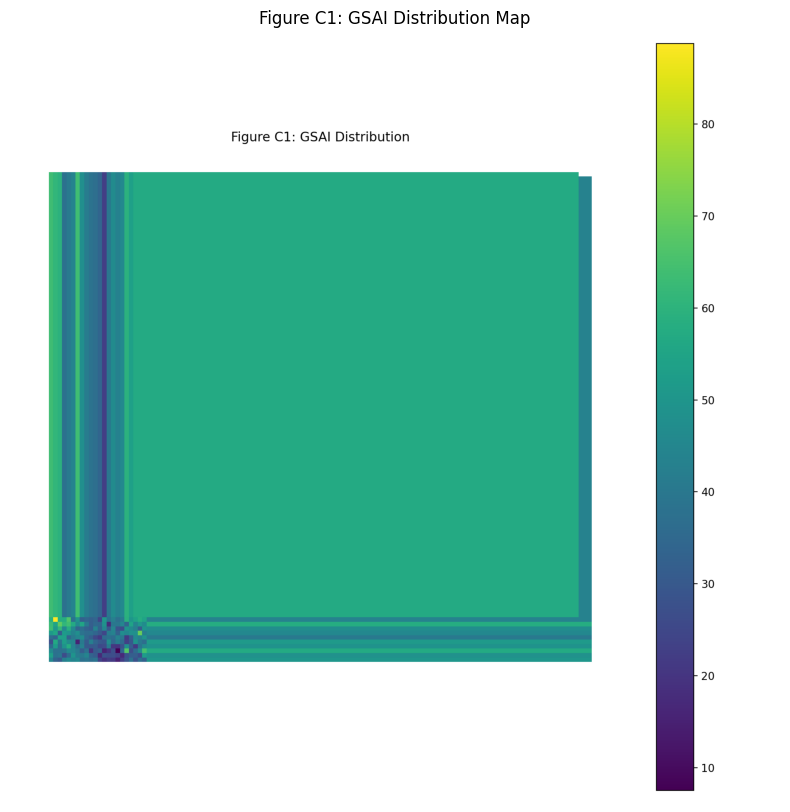

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Path to the GSAI map image
gsai_map_path = 'output/figures/figure_c1_gsai_map.png'

# Load and display the image
img = mpimg.imread(gsai_map_path)
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off') # Hide axes for image display
plt.title('Figure C1: GSAI Distribution Map')
plt.show()

In [ ]:
%run code/03_spatial/03_morans_lisa.py

Saved Moran's I and LISA outputs to output/tables and updated tracts layer.


In [ ]:
# Run the GWR analysis script
%run code/04_gwr/04_run_gwr.py

GWR complete. Wrote coefficient summary + diagnostics and updated tracts layer with local outputs.


<Figure size 640x480 with 0 Axes>

In [ ]:
# Re-running the Moran's I and LISA script after applying fixes
%run code/03_spatial/03_morans_lisa.py

Saved Moran's I and LISA outputs to output/tables and updated tracts layer.


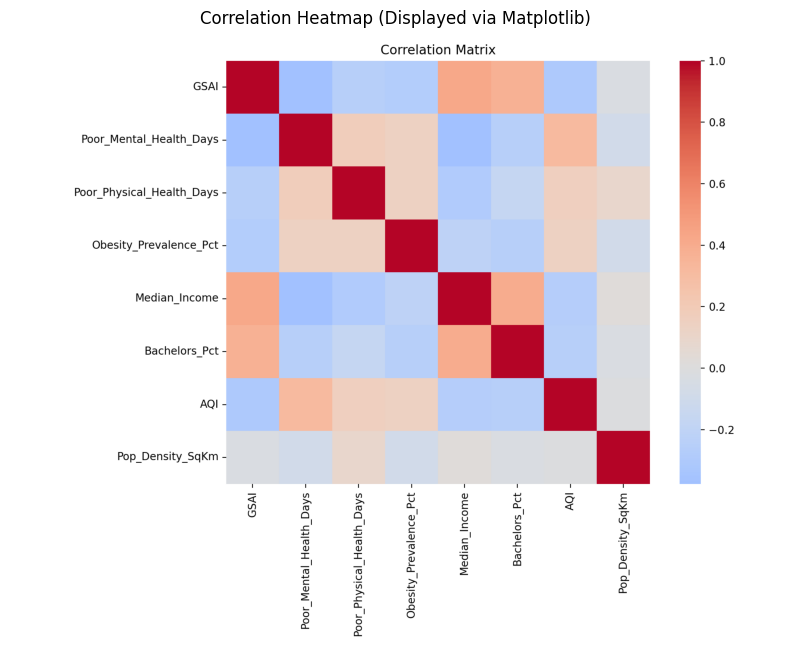

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Path to the correlation heatmap image
heatmap_path = 'output/figures/table_c1_correlation_heatmap.png'

# Load and display the image
img = mpimg.imread(heatmap_path)
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off') # Hide axes for image display
plt.title('Correlation Heatmap (Displayed via Matplotlib)')
plt.show()

Relationships Between Factors (Correlation Heatmap) - Table C1
The Correlation Heatmap (Table C1) illustrates the linear relationships between the Green Space Accessibility Index and various health, social, and economic factors. By looking at the colors and values, we can quickly identify which variables tend to move together (positive correlation) or in opposite directions (negative correlation). This helps in understanding potential associations before diving into more complex spatial analyses.


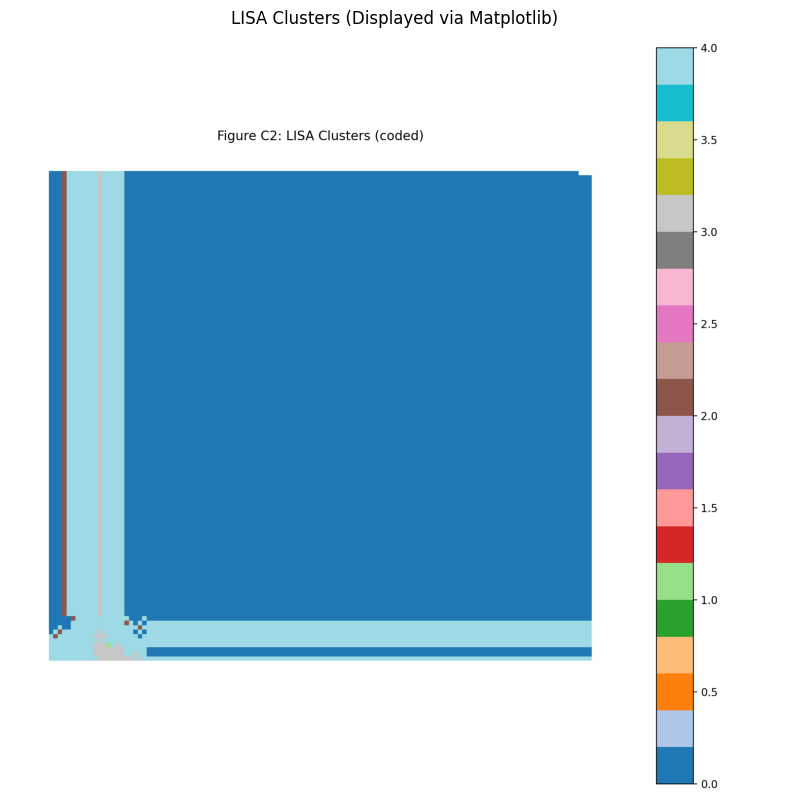

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Path to the LISA clusters image
lisa_cluster_path = 'output/figures/figure_c2_lisa_clusters.png'

# Load and display the image
img = mpimg.imread(lisa_cluster_path)
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off') # Hide axes for image display
plt.title('LISA Clusters (Displayed via Matplotlib)')
plt.show()

### GWR Local R² Surface

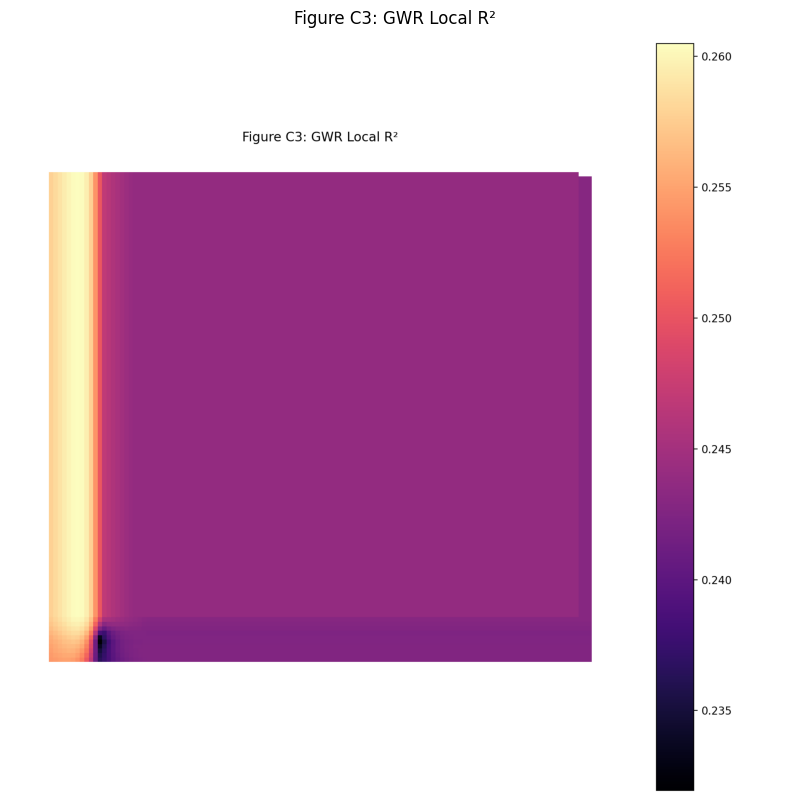

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Path to the GWR local R² image
gwr_local_r2_path = 'output/figures/figure_c3_gwr_local_r2.png'

# Load and display the image
img_local_r2 = mpimg.imread(gwr_local_r2_path)
plt.figure(figsize=(10, 10))
plt.imshow(img_local_r2)
plt.axis('off') # Hide axes for image display
plt.title('Figure C3: GWR Local R²')
plt.show()

### GWR GSAI Coefficient Surface

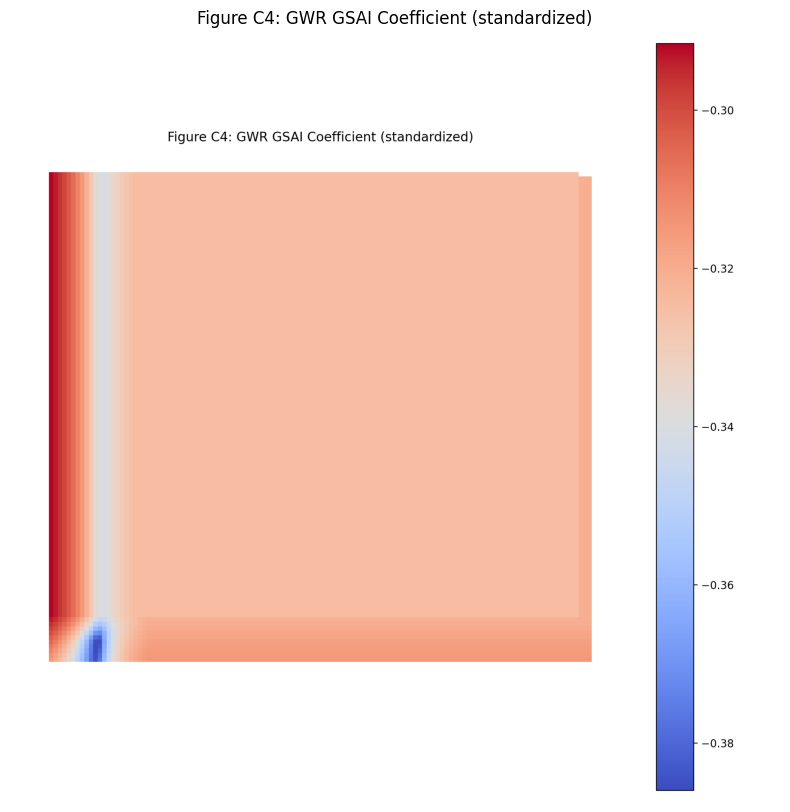

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Path to the GWR GSAI coefficient image
gwr_gsai_coef_path = 'output/figures/figure_c4_gwr_gsai_coef.png'

# Load and display the image
img_gsai_coef = mpimg.imread(gwr_gsai_coef_path)
plt.figure(figsize=(10, 10))
plt.imshow(img_gsai_coef)
plt.axis('off') # Hide axes for image display
plt.title('Figure C4: GWR GSAI Coefficient (standardized)')
plt.show()

Now that we've seen all the main visualizations, here's a summary of what they tell us:

## **Interpretation of Visualizations**

### Your Green Space Report Card (GSAI) - Figure C1

*   The **GSAI Distribution Map (Figure C1)** visually represents the Green Space Accessibility Index for each neighborhood. It clearly shows the spatial distribution of green space access, highlighting areas with high access (e.g., darker shades) versus low access (e.g., lighter shades). This map is crucial for identifying areas that might be underserved in terms of green infrastructure, like a report card for how well a neighborhood connects to nature.

### Relationships Between Factors (Correlation Heatmap) - Table C1

*   The **Correlation Heatmap (Table C1)** illustrates the linear relationships between the Green Space Accessibility Index and various health, social, and economic factors. By looking at the colors and values, we can quickly identify which variables tend to move together (positive correlation) or in opposite directions (negative correlation). This helps in understanding potential associations before diving into more complex spatial analyses – think of it as seeing which puzzle pieces fit together.

### Finding Green Space Neighborhoods (LISA Clusters) - Figure C2

*   The **LISA Clusters Map (Figure C2)** identifies spatial clusters of high or low Green Space Accessibility. It reveals "hotspots" (areas with high GSAI surrounded by other high GSAI areas) and "coldspots" (areas with low GSAI surrounded by other low GSAI areas). This information is invaluable for targeted urban planning and interventions, showing where similar conditions are geographically concentrated – like finding neighborhoods that are all getting excellent grades, or all struggling, in green space access.

### Understanding Local Relationships (GWR Local R²) - Figure C3

*   The **GWR Local R² Map (Figure C3)** displays how well our Geographically Weighted Regression model explains the variation in the dependent variable (e.g., Poor Mental Health Days) at different locations. Higher R² values (e.g., darker shades) indicate areas where the model provides a stronger fit and better explains the local relationship between green space access and mental health, while lower values suggest other local factors might be at play or the relationship is weaker. It's like a "strength meter" showing where our green space connection story is strongest.

### How GSAI's Impact Changes (GWR GSAI Coefficient) - Figure C4

*   The **GWR GSAI Coefficient Map (Figure C4)** is particularly insightful. It visualizes the estimated coefficient of the GSAI variable from the GWR model across the study area. This map shows how the *impact* or *strength* of green space accessibility on mental health varies geographically. For example, some areas might show a stronger negative relationship (more green space, fewer poor mental health days) than others, indicating that green space interventions might be more effective in certain locations. It helps us understand that the same solution might not work everywhere – a very important lesson in urban planning!

In [ ]:
import pandas as pd
from code._shared.config import TABLES

# Path to the GWR diagnostics CSV
gwr_diagnostics_path = TABLES / "gwr_diagnostics.csv"

# Load and display the CSV content
df_gwr_diagnostics = pd.read_csv(gwr_diagnostics_path)

print("GWR Diagnostic Results:")
display(df_gwr_diagnostics)

GWR Diagnostic Results:


,bandwidth,aicc,rss,enp
0,249.0,832.650364,[[199.27441664]\n [204.11000829]\n [208.214238...,10.825599


### Understanding Our GWR Model (Diagnostics)

Let's break down what these GWR diagnostic results mean – think of them as checking the engine's performance for our model:

*   **Bandwidth: 249.0**: Imagine we're doing a local analysis. This number tells us that for each spot we analyzed, the model looked at the 249 closest neighbors to make its calculations. It's like having a 'local neighborhood' of 249 points for each regression analysis, ensuring we're always looking at nearby information.
*   **AICC (Akaike Information Criterion Corrected): 832.65**: This is a fancy number that helps us compare different models. Generally, a lower AICC score means our model is doing a better job of explaining the data without being too complicated – it's finding a good balance between simplicity and accuracy.
*   **RSS (Residual Sum of Squares)**: You'll see an array of RSS values (like 199.27, 204.11, 208.21). Think of this as how much 'error' or unexplained wiggle room is left in our model. It measures the total variation in what we're trying to predict that *isn't* captured by our model. A lower RSS generally means our model is doing a better job of fitting the data.
*   **ENP (Effective Number of Parameters): 10.83**: This represents how many variables our GWR model effectively used. It's similar to degrees of freedom and gives us an idea of the model's complexity – how many factors it's really juggling to make its predictions.

## **What Did We Discover? (Key Findings Summary)**

We just went on an amazing data journey, exploring how easy it is to get to green spaces and how that might connect to people's health! Here are the cool things we found at each stage:

### Your Green Space Report Card (GSAI)

*   We successfully calculated a **Green Space Accessibility Index (GSAI)** for every single neighborhood. This score combines how close green spaces are, how much green space is around, and how easy it is to get to them. It gives us a really detailed picture of green space access, almost like a personalized report card for each community!
*   When we looked at the GSAI scores on a map (Figure C1), we could clearly see some areas were green-space-rich, while others weren't. This instantly shows us where nature's benefits are easily available and where they might be lacking.

### Finding Green Space Neighborhoods (Moran's I & LISA)

*   Our **Global Moran's I** told us something super important: green space access isn't random! If a neighborhood has high GSAI, its neighbors probably do too (and the same for low GSAI). This is called "spatial autocorrelation" – it means things tend to cluster together geographically.
*   Then, **LISA (Local Indicators of Spatial Association)** helped us zoom in and find actual "hotspots" (neighborhoods with high GSAI surrounded by other high GSAI neighborhoods) and "coldspots" (low GSAI neighborhoods surrounded by other low GSAI neighborhoods). You can see these on the map (Figure C2) and in our summary table (`lisa_cluster_counts.csv`). This is gold for urban planners, showing them exactly where to focus their efforts!

### Uncovering Local Health Secrets (Geographically Weighted Regression - GWR)

*   The GWR model was brilliant for showing us that the connection between green space access and poor mental health days (`COL_MH_DAYS`) isn't the same everywhere! It changes from neighborhood to neighborhood, influenced by other social and economic factors. This means a solution that works great in one area might not be as effective just a few blocks away!
*   The **Local R² values** (Figure C3) were like a "strength meter," showing us which areas had a stronger connection between our model's factors and mental health, and which had weaker ones. This highlights that local conditions really matter and influence how green space impacts well-being!
*   The **GSAI coefficient surface** (Figure C4) was fascinating! It revealed how the *impact* of green space access on mental health varied geographically. In some places, having more green space seemed to make a bigger positive difference for mental health than in others. This specific insight can guide where investments in green infrastructure could have the most profound positive health effects.

**In a nutshell:** This entire analysis gives us powerful insights into where green spaces are, how that affects public health at a very local level, and where we might focus our efforts to make cities healthier and happier places to live!

## **What's Next? (Limitations & Future Ideas)**

While this notebook is a fantastic start for looking at green space and health, every project has its limits and ways it can grow even cooler! Here are some things to keep in mind and exciting ideas for future work:

*   **Connectivity Score: Room for Improvement!** Right now, our connectivity score is a bit simplified. To truly match the in-depth approach of the original paper, we'd want to use advanced tools like OSMnx for a full "network analysis." This means actually mapping out street paths, considering barriers (like busy roads), and understanding how people *really* move to green spaces, not just drawing straight lines. Imagine figuring out the *actual* shortest walking path to a park, not just as-the-crow-flies distance!

*   **Handling Missing Data: Get Fancier!** Our first data script (`01_build_analysis_layer.py`) does a basic job with missing data. But to make our results even stronger and more reliable, future versions could use more sophisticated techniques like "Multiple Imputation by Chained Equations (MICE)" or other advanced methods. This helps us fill in the gaps without skewing our findings too much, leading to more accurate insights.

*   **GSAI Weights: Make Them Smart!** The current Green Space Accessibility Index (GSAI) uses fixed weights for proximity, availability, and connectivity. Imagine if we could make these weights smarter! Future work could explore how to adjust these weights dynamically, perhaps based on what local communities value most, or even using data to figure out the best balance. This would make the GSAI even more relevant to different urban settings, reflecting what's most important in each community.

*   **Causality: Correlation ≠ Causation!** Our GWR model is great at showing us *relationships* that change across space. However, it's really important to remember: **correlation does not equal causation!** Just because two things happen together doesn't mean one causes the other. To truly understand if green spaces *cause* better health, we'd need to do longer studies or use research designs that can get closer to proving cause-and-effect. Think of it like this: ice cream sales and sunburns are correlated, but ice cream doesn't *cause* sunburns; hot weather causes both!

*   **Bringing in People's Voices (Survey Data):** Our visualization script (`06_make_tables_and_figures.py`) has a spot reserved for a "word cloud" from survey responses. This is a huge opportunity! Adding real qualitative data from community surveys would bring invaluable human perspective to our analysis. It would help us understand how residents *feel* about and *experience* green spaces, perfectly aligning with the mixed-methods approach mentioned in the paper. This would add the human element to all our data!

## How to Load Your Own Data Files

To bring your local data files into this Colab notebook, follow these easy steps:

1.  **Upload the files:** On the left-hand side of your Colab interface, you'll see a folder icon (File Explorer). Click it, then click the "Upload to session storage" icon (it looks like a file with an arrow pointing up). Select the files you want to upload from your computer.
2.  **Move to `data/raw`:** Once uploaded, the files will appear in the root directory (usually `/content/`). We need to move them into our `data/raw` folder as per our project's structure. You can do this using the code below. Remember to replace `your_filename.csv` with the actual name of your file!

Let's create the `data/raw` directory first, if it doesn't already exist, and then you can use the example code to move your files.

In [ ]:
import os
import shutil

# Create the data/raw directory if it doesn't exist
# This is where you would place your raw data files if you were uploading them manually
os.makedirs('data/raw', exist_ok=True)

# Example: If you uploaded 'your_filename.csv' to /content/
# You would then move it to data/raw/
# Replace 'your_filename.csv' with the actual name of your file(s)

# Example of moving a file:
# source_path = '/content/your_filename.csv'
# destination_path = 'data/raw/your_filename.csv'

# if os.path.exists(source_path):
#     shutil.move(source_path, destination_path)
#     print(f"Moved {source_path} to {destination_path}")
# else:
#     print(f"File not found at {source_path}. Please upload your file first.")

print("The 'data/raw' directory is ready. You can now manually move or use code to move your uploaded files into it.")
print("Remember to uncomment and modify the example shutil.move lines above for each of your files!")

The 'data/raw' directory is ready. You can now manually move or use code to move your uploaded files into it.
Remember to uncomment and modify the example shutil.move lines above for each of your files!
